# HW13 — токенизация, инференс pretrained BERT-подобной модели и fine-tuning

Ниже — полный учебный пайплайн по шаблону HW13: загрузка датасета через `datasets.load_dataset(...)`, токенизация, инференс готовой модели, fine-tuning, оценка на `validation` и один финальный прогон на `test`.

In [1]:
# 0) Установка и импорты
# В чистой среде могут отсутствовать нужные пакеты.
# Если они уже установлены, команда просто быстро завершится.
%pip install -q datasets transformers protobuf sentencepiece accelerate

import os
import random
from copy import deepcopy
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import datasets
from datasets import DatasetDict
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from torch.utils.data import DataLoader
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    BertForSequenceClassification,
    BertTokenizer,
)

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 180)
pd.set_option("display.precision", 4)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ART_DIR = Path("artifacts")
ART_DIR.mkdir(exist_ok=True)

print("Python:", __import__("sys").version.split()[0])
print("datasets:", datasets.__version__)
print("transformers:", __import__("transformers").__version__)
print("torch:", torch.__version__)
print("device:", device)

Note: you may need to restart the kernel to use updated packages.
Python: 3.13.3
datasets: 4.8.4
transformers: 5.5.0
torch: 2.10.0
device: cpu


## 1. Данные и первичный анализ

In [2]:
# 1) Загрузка датасета через datasets.load_dataset(...)
# Выбрана emotion: компактный, понятный и стандартный датасет для текстовой классификации.
raw_ds = datasets.load_dataset("emotion")
label_names = raw_ds["train"].features["label"].names
id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in enumerate(label_names)}

print(raw_ds)
print("\nLabel names:", label_names)
for split in ["train", "validation", "test"]:
    print(f"{split}: {len(raw_ds[split])}")

print("\nSeveral examples:")
for i in range(5):
    row = raw_ds["train"][i]
    print(f"Example {i+1} | label={row['label']} ({id2label[row['label']]})")
    print(row["text"])
    print("-")

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Label names: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
train: 16000
validation: 2000
test: 2000

Several examples:
Example 1 | label=0 (sadness)
i didnt feel humiliated
-
Example 2 | label=0 (sadness)
i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
-
Example 3 | label=3 (anger)
im grabbing a minute to post i feel greedy wrong
-
Example 4 | label=2 (love)
i am ever feeling nostalgic about the fireplace i will know that it is still on the property
-
Example 5 | label=3 (anger)
i am feeling grouchy
-


## 2. Токенизация

In [3]:
# 2) Токенизация: базовый разбор нескольких текстов
# Используем slow BERT tokenizer через from_pretrained, чтобы не зависеть от fast-tokenizer пути.
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

print("Tokenizer class:", tokenizer.__class__.__name__)
print("Special tokens:", tokenizer.special_tokens_map)

texts_for_demo = [raw_ds["train"][i]["text"] for i in range(3)]
for i, text in enumerate(texts_for_demo, 1):
    tokens = tokenizer.tokenize(text)
    enc = tokenizer(text, add_special_tokens=True, padding="max_length", truncation=True, max_length=24)
    print(f"\n--- Example {i} ---")
    print("Text:", text)
    print("Tokens:", tokens)
    print("input_ids:", enc["input_ids"])
    print("attention_mask:", enc["attention_mask"])
    print("CLS/SEP present:", enc["input_ids"][0], enc["input_ids"][enc["attention_mask"].index(0)-1 if 0 in enc["attention_mask"] else -1])

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer class: BertTokenizer
Special tokens: {'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}

--- Example 1 ---
Text: i didnt feel humiliated
Tokens: ['i', 'didn', '##t', 'feel', 'humiliated']
input_ids: [101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
CLS/SEP present: 101 102

--- Example 2 ---
Text: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Tokens: ['i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake']
input_ids: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102, 0]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

## 3. Инференс готовой pretrained модели

In [4]:
# 3) Готовая pretrained BERT-подобная модель для инференса
# Она не дообучалась на emotion, поэтому на примерах из emotion результаты будут не идеальными,
# но сам pipeline инференса должен работать корректно.
ready_tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased-finetuned-sst-2-english",
    use_fast=False,
)
ready_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased-finetuned-sst-2-english"
).to(device)
ready_model.eval()

inference_texts = [
    "I am very happy and excited today!",
    "I feel terrible and upset about what happened.",
    "This is surprising and unexpected.",
    "I love my friends and family so much.",
    "The situation makes me furious and angry.",
]

enc = ready_tokenizer(
    inference_texts,
    padding=True,
    truncation=True,
    max_length=64,
    return_tensors="pt",
).to(device)
with torch.no_grad():
    logits = ready_model(**enc).logits
    probs = torch.softmax(logits, dim=-1).cpu().numpy()
    pred_ids = probs.argmax(axis=1)

ready_label_names = ready_model.config.id2label
if not ready_label_names or ready_label_names.get(0, None) is None:
    ready_label_names = {0: "NEGATIVE", 1: "POSITIVE"}

ready_pred_labels = [ready_label_names[int(i)] for i in pred_ids]
ready_conf = probs.max(axis=1)

ready_df = pd.DataFrame({
    "text": inference_texts,
    "pred_label": ready_pred_labels,
    "confidence": ready_conf,
})
display(ready_df)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

,text,pred_label,confidence
0,I am very happy and excited today!,POSITIVE,0.9999
1,I feel terrible and upset about what happened.,NEGATIVE,0.9990
2,This is surprising and unexpected.,POSITIVE,0.9999
3,I love my friends and family so much.,POSITIVE,0.9999
4,The situation makes me furious and angry.,NEGATIVE,0.9988


## 4. Подготовка токенизации датасета для fine-tuning

In [5]:
# 4) Явная подготовка токенизации датасета для fine-tuning
max_length = 64

def tokenize_dataset(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=max_length,
    )

tokenized_ds = raw_ds.map(tokenize_dataset, batched=True)
tokenized_ds = tokenized_ds.remove_columns(["text"])
tokenized_ds = tokenized_ds.rename_column("label", "labels")
tokenized_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

print(tokenized_ds)
print(tokenized_ds["train"][0])

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})
{'labels': tensor(0), 'input_ids': tensor([  101,  1045,  2134,  2102,  2514, 26608,   102,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 

## 5. Fine-tuning BERT-подобной модели

In [6]:
# 5) Fine-tuning одной BERT-подобной модели
# Для ускорения используем компактную архитектуру, но всё равно с pretrained from_pretrained(...).
model = BertForSequenceClassification.from_pretrained(
    "prajjwal1/bert-tiny",
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
).to(device)

batch_size = 16
max_epochs = 2
learning_rate = 5e-5

train_loader = DataLoader(tokenized_ds["train"], batch_size=batch_size, shuffle=True)
val_loader = DataLoader(tokenized_ds["validation"], batch_size=batch_size, shuffle=False)
test_loader = DataLoader(tokenized_ds["test"], batch_size=batch_size, shuffle=False)

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)


def evaluate(model, loader):
    model.eval()
    all_true, all_pred, all_prob = [], [], []
    total_loss = 0.0
    with torch.no_grad():
        for batch in loader:
            labels = batch["labels"].to(device)
            inputs = {
                "input_ids": batch["input_ids"].to(device),
                "attention_mask": batch["attention_mask"].to(device),
                "labels": labels,
            }
            outputs = model(**inputs)
            total_loss += outputs.loss.item()
            probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()
            preds = probs.argmax(axis=1)
            all_true.extend(labels.cpu().numpy().tolist())
            all_pred.extend(preds.tolist())
            all_prob.extend(probs.tolist())
    return {
        "loss": total_loss / max(1, len(loader)),
        "accuracy": accuracy_score(all_true, all_pred),
        "f1_macro": f1_score(all_true, all_pred, average="macro"),
    }, np.array(all_true), np.array(all_pred), np.array(all_prob)


best_state = deepcopy(model.state_dict())
best_val_acc = -1.0
history = []

for epoch in range(1, max_epochs + 1):
    model.train()
    total_loss = 0.0
    for batch in train_loader:
        labels = batch["labels"].to(device)
        inputs = {
            "input_ids": batch["input_ids"].to(device),
            "attention_mask": batch["attention_mask"].to(device),
            "labels": labels,
        }
        optimizer.zero_grad()
        outputs = model(**inputs)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    train_loss = total_loss / max(1, len(train_loader))
    val_metrics, _, _, _ = evaluate(model, val_loader)
    history.append({"epoch": epoch, "train_loss": train_loss, **val_metrics})
    print(
        f"epoch={epoch:02d} train_loss={train_loss:.4f} "
        f"val_loss={val_metrics['loss']:.4f} val_accuracy={val_metrics['accuracy']:.4f} "
        f"val_f1_macro={val_metrics['f1_macro']:.4f}"
    )
    if val_metrics["accuracy"] >= best_val_acc:
        best_val_acc = val_metrics["accuracy"]
        best_state = deepcopy(model.state_dict())

history_df = pd.DataFrame(history)
display(history_df)

model.load_state_dict(best_state)

pytorch_model.bin:   0%|          | 0.00/17.8M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: prajjwal1/bert-tiny
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect i

model.safetensors:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

epoch=01 train_loss=1.2190 val_loss=0.6644 val_accuracy=0.8155 val_f1_macro=0.7759
epoch=02 train_loss=0.4990 val_loss=0.3652 val_accuracy=0.8805 val_f1_macro=0.8537


,epoch,train_loss,loss,accuracy,f1_macro
0,1,1.219,0.6644,0.8155,0.7759
1,2,0.499,0.3652,0.8805,0.8537


<All keys matched successfully>

## 6. Финальная оценка на test и артефакты

Test metrics:
{'loss': 0.33744876557588577, 'accuracy': 0.887, 'f1_macro': 0.8382891164960137}


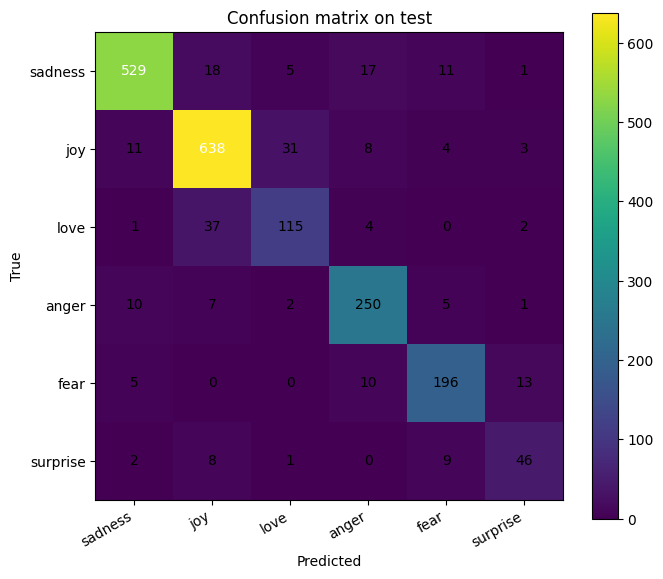

,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambitious right now,sadness,sadness,0.9223
1,im updating my blog because i feel shitty,sadness,sadness,0.9519
2,i never make her separate from me because i don t ever want her to feel like i m ashamed with her,sadness,sadness,0.9506
3,i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived,joy,joy,0.9567
4,i was feeling a little vain when i did this one,sadness,sadness,0.9491
5,i cant walk into a shop anywhere where i do not feel uncomfortable,fear,fear,0.8307
6,i felt anger when at the end of a telephone call,anger,anger,0.5482
7,i explain why i clung to a relationship with a boy who was in many ways immature and uncommitted despite the excitem...,joy,joy,0.5924
8,i like to have the same breathless feeling as a reader eager to see what will happen next,joy,joy,0.9545
9,i jest i feel grumpy tired and pre menstrual which i probably am but then again its only been a week and im about as...,anger,anger,0.8575


Saved: artifacts/sample_predictions.csv
Saved: artifacts/confusion_matrix.png


In [7]:
# 6) Один финальный прогон на test
# Модель выбиралась по validation, test используется ровно один раз для финальной оценки.
test_metrics, y_true, y_pred, y_prob = evaluate(model, test_loader)
print("Test metrics:")
print(test_metrics)

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(label_names))))
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, interpolation="nearest")
ax.set_title("Confusion matrix on test")
fig.colorbar(im, ax=ax)
ax.set_xticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=30, ha="right")
ax.set_yticks(range(len(label_names)))
ax.set_yticklabels(label_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.tight_layout()
fig.savefig(ART_DIR / "confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)

sample_predictions = pd.DataFrame({
    "text": raw_ds["test"]["text"],
    "true_label": [id2label[int(i)] for i in y_true],
    "pred_label": [id2label[int(i)] for i in y_pred],
    "confidence": y_prob.max(axis=1),
})
sample_predictions.to_csv(ART_DIR / "sample_predictions.csv", index=False)

display(sample_predictions.head(10))
print("Saved:", ART_DIR / "sample_predictions.csv")
print("Saved:", ART_DIR / "confusion_matrix.png")